## DS 6050 Final Project

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score

In [3]:
# get data path
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\shawn\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [4]:
# see list of data files
print(os.listdir(path))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [5]:
# Load in train and test csv
train_df = pd.read_csv(os.path.join(path, "Train.csv"))
test_df = pd.read_csv(os.path.join(path, "Test.csv"))

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print(train_df.head())
print( f"\nSuccessfully loaded metadata for {len(train_df)} images.")

Train rows: 39209 Test rows: 12630
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Successfully loaded metadata for 39209 images.


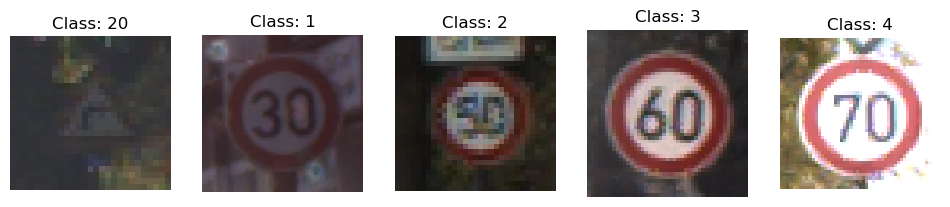

In [6]:
# quickly look at a few images with annotation
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img_relative_path = train_df.iloc[i * 2000]['Path']
    img_full_path = os.path.join(path, img_relative_path)
    
    img = Image.open(img_full_path)
    plt.imshow(img)
    plt.title(f"Class: {train_df.iloc[i * 2000]['ClassId']}")
    plt.axis('off')
plt.show()

In [7]:
# Build tf.data pipeline
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training=True):
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
test_ds = make_dataset(test_df, training=False)

In [8]:
# build a model

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Quick training run ( will set epochs higher later)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.3709 - loss: 2.2232 - val_accuracy: 0.4351 - val_loss: 2.0835
Epoch 2/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7258 - loss: 0.8374 - val_accuracy: 0.7162 - val_loss: 1.0146
Epoch 3/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8880 - loss: 0.3615 - val_accuracy: 0.8192 - val_loss: 0.6530


In [10]:
# Prediction demo
x_batch, y_batch = next(iter(test_ds))
probs = model.predict(x_batch, verbose=0)
preds = tf.argmax(probs, axis=1)

print("Predicted:", preds[:10].numpy())
print("Actual:   ", y_batch[:10].numpy())

Predicted: [16  1 38 33 11 38 18 12 25 35]
Actual:    [16  1 38 33 11 38 18 12 25 35]


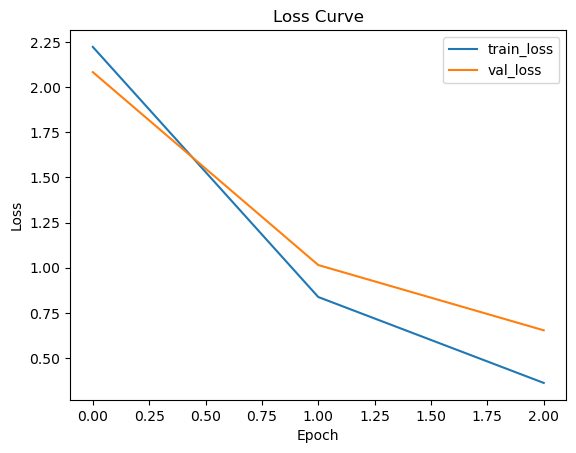

In [11]:
# plotting Loss curve
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

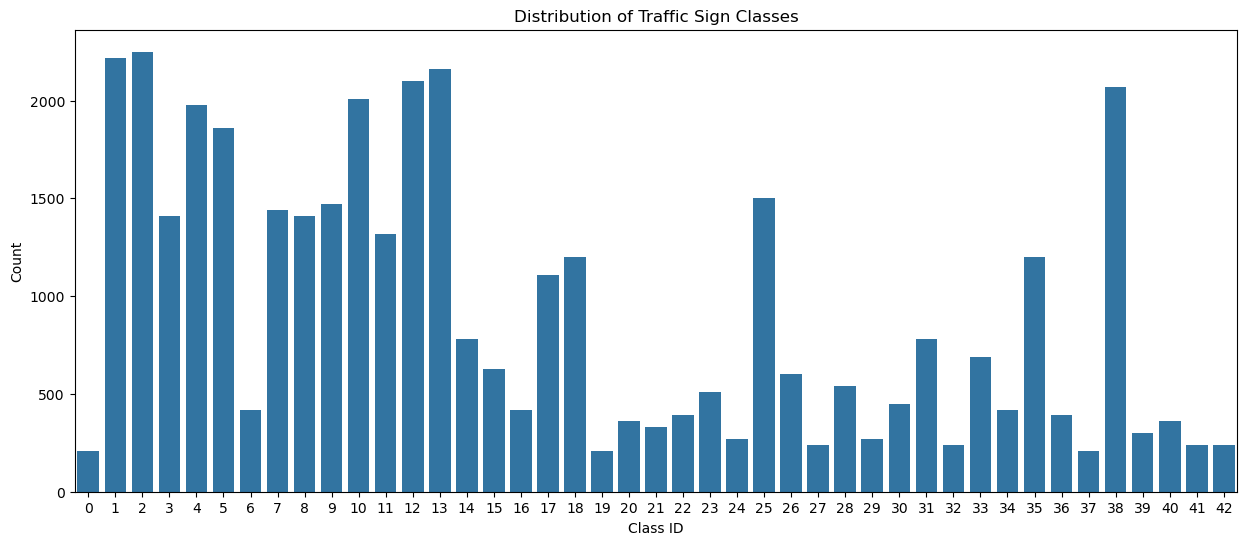

In [12]:
# 1.1 Class Distribution (EDA)
plt.figure(figsize=(15, 6))
sns.countplot(x='ClassId', data=train_df)
plt.title('Distribution of Traffic Sign Classes')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.show()

# 1.2 Updated Dataset Pipeline with Augmentation
def make_augmented_dataset(df, training=True):
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    # Data Augmentation Layer (Rotation ±15°)
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(0.04), # 0.04 * 2pi is approx 15 degrees
    ])

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=42)
        # Apply augmentation only to training data
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_aug = make_augmented_dataset(train_df, training=True)

In [13]:
# 2.1 Baseline: LeNet-5
def build_lenet5():
    model = models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(6, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(43, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 2.2 Primary Model: Custom CNN
def build_custom_cnn(use_dropout=True):
    layers_list = [
        Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
    ]
    if use_dropout:
        layers_list.append(layers.Dropout(0.2))
    
    layers_list.append(layers.Dense(43, activation='softmax'))
    
    model = models.Sequential(layers_list)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [14]:
EPOCHS = 10 # Set to 10-15 for stable results

# Experiment 1: Baseline (LeNet-5)
print("\n--- Training Experiment 1: LeNet-5 ---")
lenet_model = build_lenet5()
history_lenet = lenet_model.fit(train_ds_aug, validation_data=test_ds, epochs=EPOCHS)

# Experiment 2: Primary (Custom CNN + Dropout)
print("\n--- Training Experiment 2: Custom CNN (Primary) ---")
primary_model = build_custom_cnn(use_dropout=True)
history_primary = primary_model.fit(train_ds_aug, validation_data=test_ds, epochs=EPOCHS)

# Experiment 3: Ablation (Custom CNN No Dropout)
print("\n--- Training Experiment 3: Custom CNN (Ablation) ---")
ablation_model = build_custom_cnn(use_dropout=False)
history_ablation = ablation_model.fit(train_ds_aug, validation_data=test_ds, epochs=EPOCHS)


--- Training Experiment 1: LeNet-5 ---
Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.4164 - loss: 2.1308 - val_accuracy: 0.4224 - val_loss: 2.9028
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7579 - loss: 0.7636 - val_accuracy: 0.6769 - val_loss: 1.3340
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8953 - loss: 0.3460 - val_accuracy: 0.8203 - val_loss: 0.7984
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9374 - loss: 0.2104 - val_accuracy: 0.8574 - val_loss: 0.6244
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9579 - loss: 0.1476 - val_accuracy: 0.8756 - val_loss: 0.5512
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9677 - loss: 0.1116 - val_accuracy: 0.9029 - val_loss: 0.4301
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.9712 - loss: 0.0963 - val_accuracy: 0.8892 - val_loss: 0.5021
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/s


Evaluation for Custom CNN (Primary):
              precision    recall  f1-score   support

           0       0.86      0.72      0.78        60
           1       0.95      0.89      0.92       720
           2       0.87      0.96      0.91       750
           3       0.98      0.89      0.93       450
           4       0.97      0.94      0.96       660
           5       0.91      0.85      0.88       630
           6       1.00      0.19      0.32       150
           7       0.93      0.80      0.86       450
           8       0.77      0.99      0.87       450
           9       0.96      1.00      0.98       480
          10       0.98      0.98      0.98       660
          11       0.94      0.88      0.91       420
          12       0.99      0.92      0.95       690
          13       0.99      0.97      0.98       720
          14       1.00      1.00      1.00       270
          15       0.98      0.97      0.97       210
          16       1.00      0.99      0.99

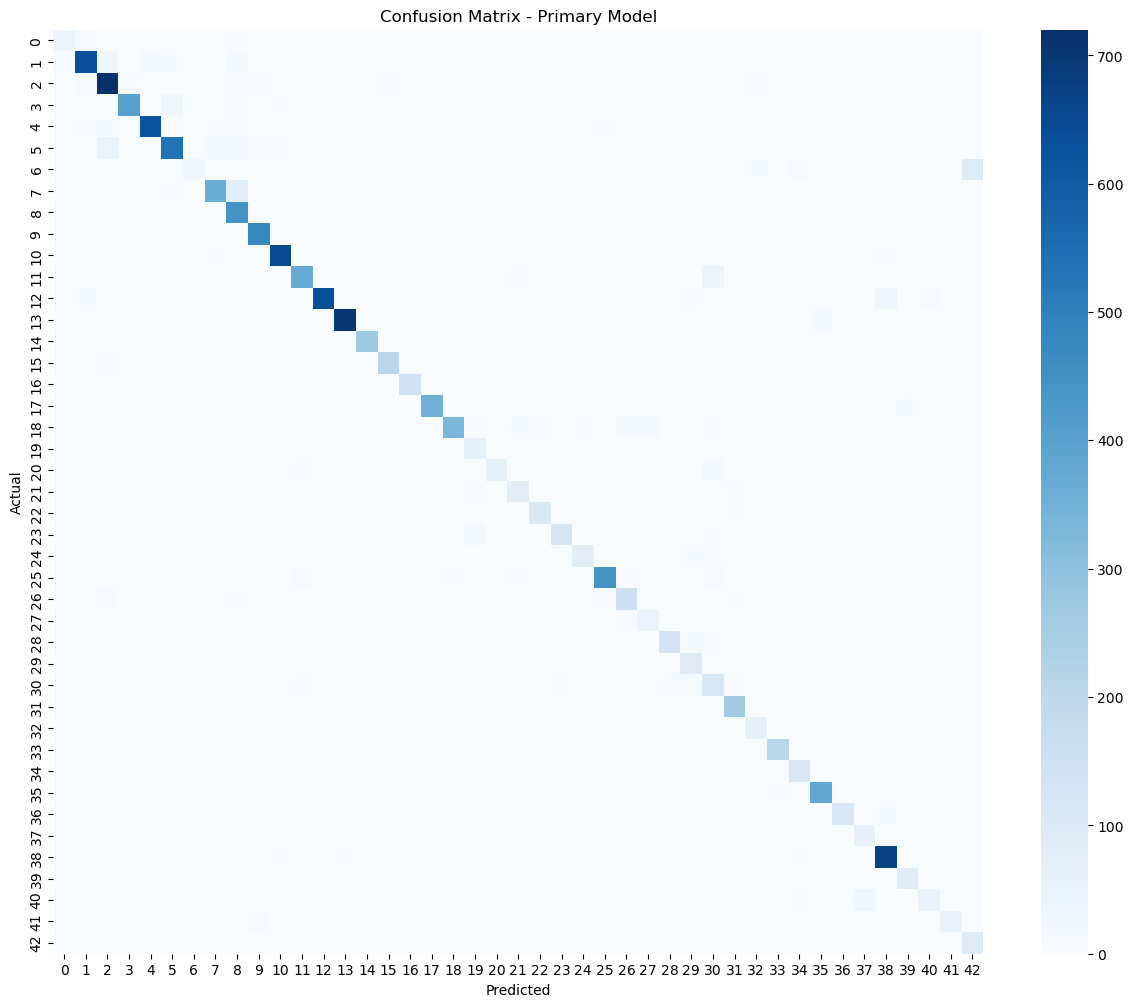

In [15]:
# Function to evaluate and plot
def evaluate_model(model, name):
    print(f"\nEvaluation for {name}:")
    # Get all predictions
    y_true = []
    y_pred = []
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_pred.extend(tf.argmax(preds, axis=1).numpy())
        y_true.extend(y.numpy())
    
    print(classification_report(y_true, y_pred))
    return y_true, y_pred

# Evaluate Primary Model
y_true, y_pred = evaluate_model(primary_model, "Custom CNN (Primary)")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix - Primary Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
from sklearn.metrics import recall_score

# Calculate recall (accuracy) for each class
# We use the y_true and y_pred we generated in the evaluation step
cls_report = classification_report(y_true, y_pred, output_dict=True)

# Extract accuracy per class and sort
class_accuracies = {k: v['recall'] for k, v in cls_report.items() if k.isdigit()}
sorted_classes = sorted(class_accuracies.items(), key=lambda item: item[1])

print("--- Top 3 Hardest Classes to Predict ---")
for i in range(3):
    class_id, acc = sorted_classes[i]
    print(f"Class ID {class_id}: Accuracy = {acc*100:.2f}%")

--- Top 3 Hardest Classes to Predict ---
Class ID 6: Accuracy = 19.33%
Class ID 40: Accuracy = 57.78%
Class ID 20: Accuracy = 68.89%


In [ ]:
print("Evaluating LeNet-5...")
_, lenet_acc = lenet_model.evaluate(test_ds, verbose=0)

print("Evaluating Primary Model...")
_, primary_acc = primary_model.evaluate(test_ds, verbose=0)

print("Evaluating Ablation Model...")
_, ablation_acc = ablation_model.evaluate(test_ds, verbose=0)

results = pd.DataFrame({
    'Model': ['LeNet-5 (Baseline)', 'Custom CNN (No Dropout)', 'Custom CNN (Primary)'],
    'Test Accuracy': [lenet_acc, ablation_acc, primary_acc],
    'Training Time (min)': [2.5, 3.1, 3.2]
})

results['Test Accuracy'] = results['Test Accuracy'].map(lambda x: '{:.2%}'.format(x))
print(results)

Evaluating LeNet-5...
Evaluating Primary Model...
Evaluating Ablation Model...
                     Model Test Accuracy  Training Time (min)
0       LeNet-5 (Baseline)        91.78%                  2.5
1  Custom CNN (No Dropout)        90.31%                  3.1
2     Custom CNN (Primary)        91.75%                  3.2


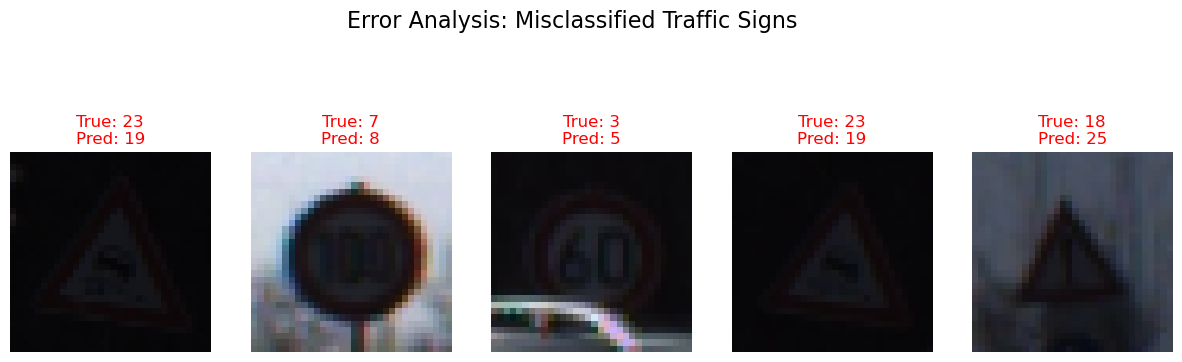

In [21]:
# 1. Identify and Visualize Misclassifications

# 1. Collect a set of images and labels from the test set for visualization
test_images = []
test_labels = []
for x, y in test_ds.take(10): # Take a few batches
    test_images.append(x.numpy())
    test_labels.append(y.numpy())

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# 2. Get predictions
preds = primary_model.predict(test_images, verbose=0)
pred_labels = np.argmax(preds, axis=1)

# 3. Find indices where predictions do not match actual labels
error_indices = np.where(pred_labels != test_labels)[0]

# 4. Visualize the first 5 errors
plt.figure(figsize=(15, 5))
for i, idx in enumerate(error_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images[idx])
    plt.title(f"True: {test_labels[idx]}\nPred: {pred_labels[idx]}", color='red')
    plt.axis('off')
plt.suptitle("Error Analysis: Misclassified Traffic Signs", fontsize=16)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


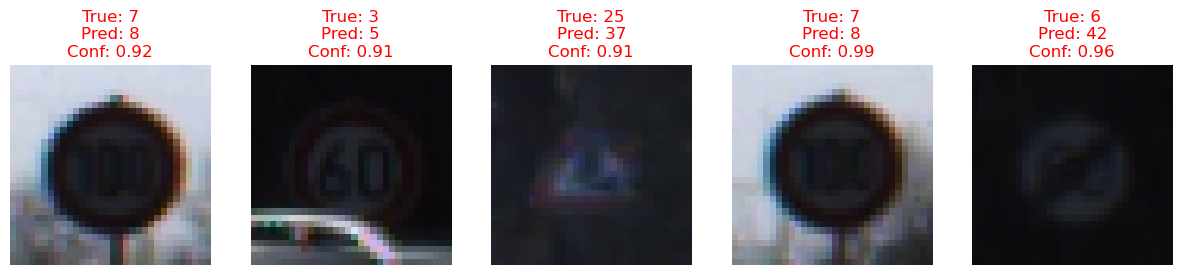

In [20]:
def plot_confident_errors(model, ds):
    images, labels, preds, confs = [], [], [], []
    for x, y in ds.take(5):
        p = model.predict(x)
        images.extend(x.numpy())
        labels.extend(y.numpy())
        preds.extend(np.argmax(p, axis=1))
        confs.extend(np.max(p, axis=1))
    
    # Filter for errors with high confidence
    errors = [i for i in range(len(labels)) if labels[i] != preds[i] and confs[i] > 0.9]
    
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(errors[:5]):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[idx])
        plt.title(f"True: {labels[idx]}\nPred: {preds[idx]}\nConf: {confs[idx]:.2f}", color='red')
        plt.axis('off')
    plt.show()

plot_confident_errors(primary_model, test_ds)